In [4]:
!pip install xgboost

In [5]:
!pip install lightgbm

 Found 4 highly correlated features to drop:
['merchant_location_lon', 'is_unique_users_on_device_outlier', 'pattern_suspicious_ip', 'pattern_fraud_ring']

 Found 7 irrelevant features to drop (corr with target < 0.01):
['user_transaction_count', 'is_amount_missing', 'txn_month', 'txn_is_weekend', 'user_category_affinity', 'pay_Wallet', 'transaction_status_pending']

 Original Data Shape: (1426, 50)
 Final Data Shape: (1426, 39)


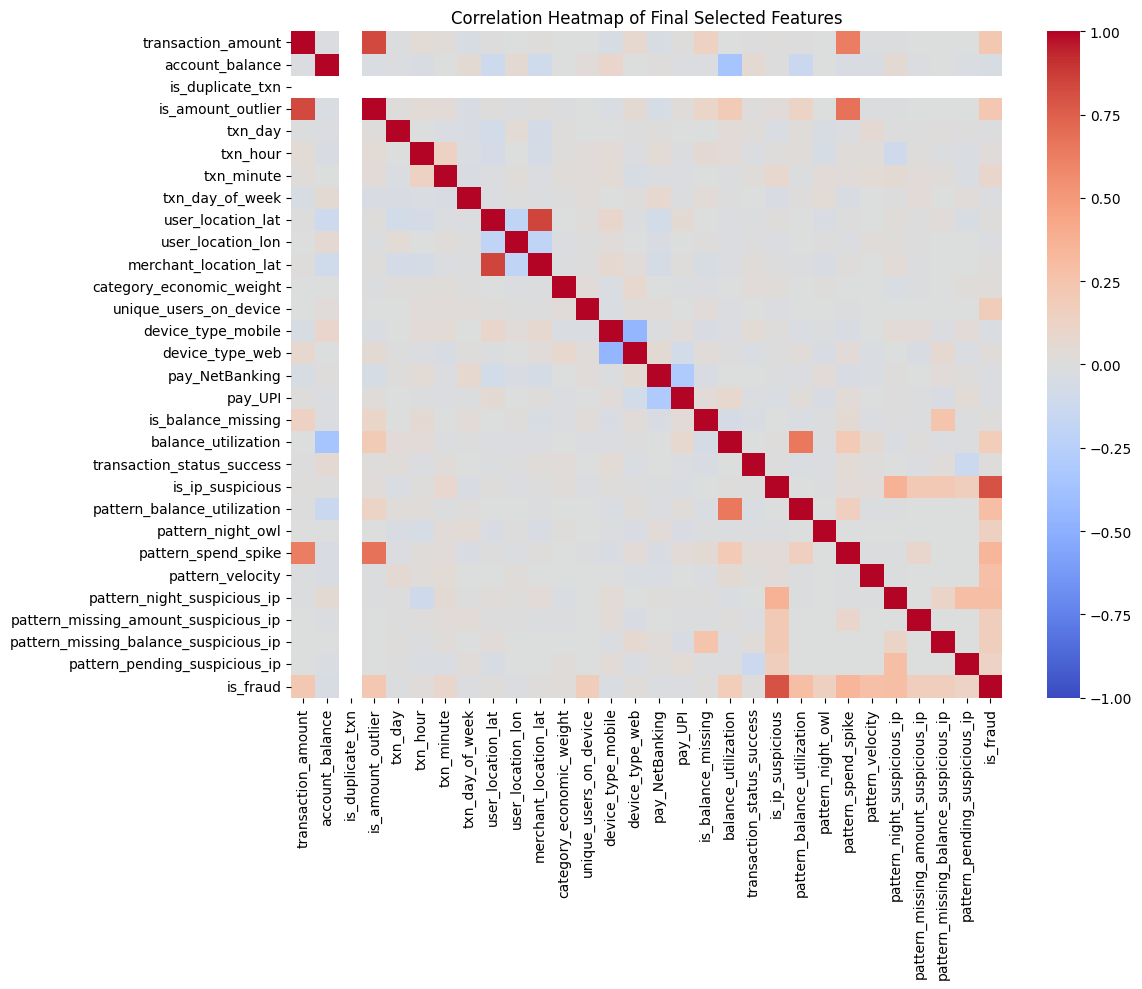

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# =====================================================================
# 1. LOAD DATA & PREPARE NUMERICAL COLUMNS
# =====================================================================
df = pd.read_csv('fraud_flagged_output.csv')

df.drop("Unnamed: 0",axis=1,inplace=True)

# Correlation only works on numbers. We isolate numeric columns.
# We also exclude the target variable 'is_fraud' from the dropping logic for now.
numeric_df = df.select_dtypes(include=[np.number])
features_only = numeric_df.drop(columns=['is_fraud'], errors='ignore')

# =====================================================================
# 2. FIND AND DROP HIGHLY CORRELATED FEATURES (Collinearity)
# =====================================================================
CORRELATION_THRESHOLD = 0.85  # If two features are 85% identical, drop one

# Calculate the absolute correlation matrix
corr_matrix = features_only.corr().abs()

# Select the upper triangle of the correlation matrix
# (This prevents us from dropping BOTH features in a correlated pair)
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find columns where correlation is greater than our threshold
to_drop_collinear = [column for column in upper_triangle.columns if any(upper_triangle[column] > CORRELATION_THRESHOLD)]

print(f" Found {len(to_drop_collinear)} highly correlated features to drop:")
print(to_drop_collinear)

# Drop them from the main dataframe
df_reduced = df.drop(columns=to_drop_collinear)

# =====================================================================
# 3. DROP IRRELEVANT FEATURES (Low Target Correlation)
# =====================================================================
# Now we check how well the remaining features predict 'is_fraud'
TARGET_CORR_THRESHOLD = 0.01  # If correlation with target is < 1%, it's useless noise

# Recalculate correlation with the target using the reduced dataset
target_corr = df_reduced.select_dtypes(include=[np.number]).corr()['is_fraud'].abs()

# Find features that have almost zero relationship with the fraud flag
to_drop_irrelevant = target_corr[target_corr < TARGET_CORR_THRESHOLD].index.tolist()

# Ensure we don't accidentally drop 'is_fraud' or ID columns
safe_cols = ['is_fraud', 'user_id', 'transaction_id']
to_drop_irrelevant = [col for col in to_drop_irrelevant if col not in safe_cols]

print(f"\n Found {len(to_drop_irrelevant)} irrelevant features to drop (corr with target < {TARGET_CORR_THRESHOLD}):")
print(to_drop_irrelevant)

df_final = df_reduced.drop(columns=to_drop_irrelevant)

# =====================================================================
# 4. RESULTS & VISUALIZATION (Optional but highly recommended)
# =====================================================================
print(f"\n Original Data Shape: {df.shape}")
print(f" Final Data Shape: {df_final.shape}")

# Optional: Plot a heatmap of the surviving features to prove to the judges
# that your final dataset has no multicollinearity.
plt.figure(figsize=(12, 10))
sns.heatmap(df_final.select_dtypes(include=[np.number]).corr(),
            annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Heatmap of Final Selected Features")
plt.tight_layout()
plt.show()

# Save your optimized dataset
# df_final.to_csv('model_ready_data.csv', index=False)

 Scoring features based on Mutual Information (Information Gain)...

 Dataset mathematically reduced from 29 features down to 15.
 Final Ultra-Lean Data Shape: (1426, 18)


/tmp/ipykernel_7507/2571659815.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Information_Score', y='Feature', data=feature_scores.head(TOP_N_FEATURES), palette='magma')


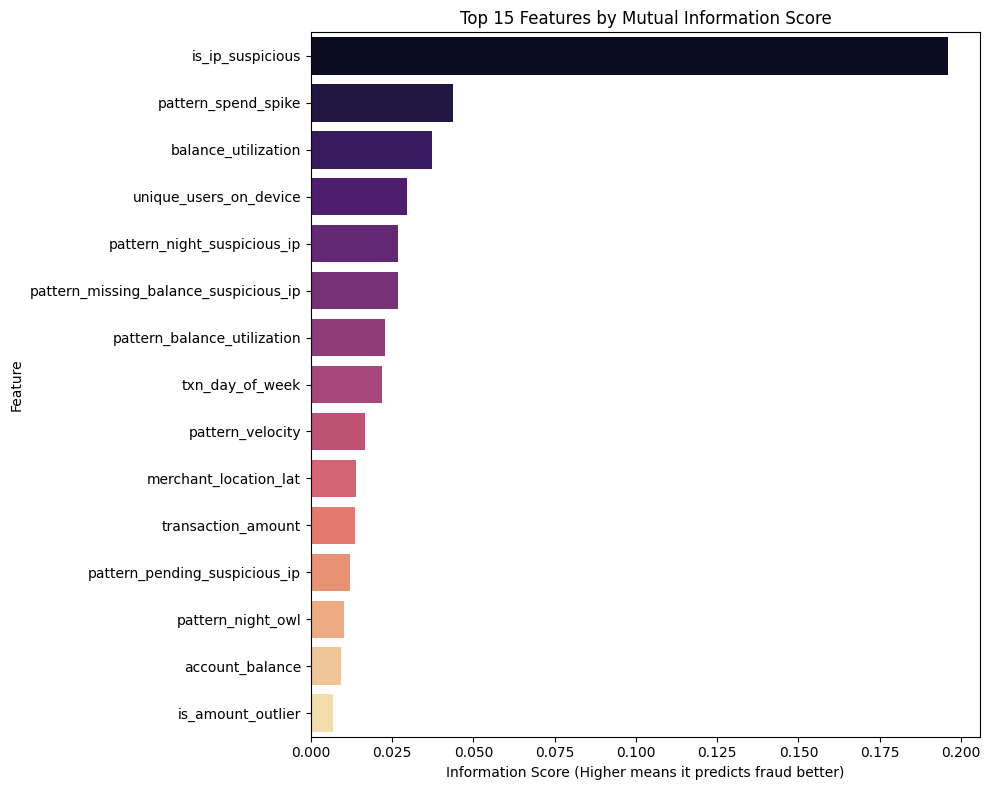

In [7]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# 1. PREPARE THE DATA
# =====================================================================
# Isolate just the predictive numbers (X) and the target (y)
X = df_final.drop(columns=['is_fraud', 'user_id', 'transaction_id'], errors='ignore')
X = X.select_dtypes(include=[np.number]) # Ensure strictly numeric
y = df_final['is_fraud']

# =====================================================================
# 2. SCORE FEATURES USING MUTUAL INFORMATION
# =====================================================================
print(" Scoring features based on Mutual Information (Information Gain)...")

# We explicitly tell the algorithm to pick the 15 best features
TOP_N_FEATURES = 15
selector = SelectKBest(score_func=mutual_info_classif, k=TOP_N_FEATURES)
selector.fit(X, y)

# Create a clean dataframe of the scores so we can see the rankings
feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Information_Score': selector.scores_
}).sort_values(by='Information_Score', ascending=False)

# =====================================================================
# 3. BUILD THE FINAL 15-FEATURE DATASET
# =====================================================================
# Extract the names of the top 15 features
top_features_list = feature_scores['Feature'].head(TOP_N_FEATURES).tolist()

# Rebuild the dataset with IDs, target, and exactly 15 features
cols_to_keep = ['user_id', 'transaction_id', 'is_fraud'] + top_features_list
df_ultra_lean = df_final[cols_to_keep]


# =====================================================================
# 4. VISUALIZATION & RESULTS
# =====================================================================
print(f"\n Dataset mathematically reduced from {X.shape[1]} features down to {TOP_N_FEATURES}.")
print(f" Final Ultra-Lean Data Shape: {df_ultra_lean.shape}")

# Plot the results for your hackathon presentation
plt.figure(figsize=(10, 8))
sns.barplot(x='Information_Score', y='Feature', data=feature_scores.head(TOP_N_FEATURES), palette='magma')
plt.title(f'Top {TOP_N_FEATURES} Features by Mutual Information Score')
plt.xlabel('Information Score (Higher means it predicts fraud better)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

 #Save the final dataset
df_ultra_lean.to_csv('15_features_dataset.csv', index=False)

In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, log_loss
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import warnings

# Keep the output clean from warnings
warnings.filterwarnings('ignore')

print("=== STAGE 1: LOADING & PREPARING DATA ===")
df = pd.read_csv('15_features_dataset.csv')

# Drop the engineered patterns and IDs so the AI learns from the raw data, not our cheatsheet
cols_to_drop = ['is_fraud', 'transaction_id', 'user_id', 'device_id', 'transaction_timestamp', 'Unnamed: 0']

X = df.drop(columns=[col for col in cols_to_drop if col in df.columns], errors='ignore')
X = X.select_dtypes(include=['int64', 'float64']) # AI only accepts numbers
y = df['is_fraud']

# Calculate ratio to help XGBoost handle imbalanced data (if frauds are rare)
ratio = float(np.sum(y == 0)) / np.sum(y == 1) if np.sum(y == 1) > 0 else 1.0

# Train/Test Split (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training on {len(X_train)} rows, Testing on {len(X_test)} rows.\n")


print("=== STAGE 2: ALGORITHM SHOOTOUT (GRID SEARCH) ===")

# 1. Define the models we want to test
models = {
    "Random Forest": RandomForestClassifier(random_state=42, class_weight='balanced'),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=ratio),
    "LightGBM": LGBMClassifier(random_state=42, class_weight='balanced', verbosity=-1)
}

# 2. Define the settings (Grid) we want to test for each model
param_grids = {
    "Random Forest": {
        'n_estimators': [50, 100],
        'max_depth': [None, 10, 20]
    },
    "XGBoost": {
        'n_estimators': [50, 100],
        'max_depth': [3, 6],
        'learning_rate': [0.01, 0.1]
    },
    "LightGBM": {
        'n_estimators': [50, 100],
        'max_depth': [-1, 10],
        'learning_rate': [0.01, 0.1]
    }
}

best_overall_model = None
best_overall_score = -1
best_model_name = ""

# 3. Loop through each model and find the best settings
for name, model in models.items():
    print(f"\n Training {name}...")

    # Run GridSearch (cv=3 means it double-checks its work 3 times)
    grid = GridSearchCV(estimator=model, param_grid=param_grids[name], cv=3, scoring='f1_macro', n_jobs=-1)
    grid.fit(X_train, y_train)
    print(f"Best {name} Parameters: {grid.best_params_}")

    # Grab the best version of the current model
    best_current_model = grid.best_estimator_

    # Make predictions on BOTH Train and Test data to check for overfitting
    y_train_pred = best_current_model.predict(X_train)
    y_test_pred = best_current_model.predict(X_test)
    y_test_pred_proba = best_current_model.predict_proba(X_test)

    # Calculate Train Accuracy vs Test Accuracy
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    test_loss = log_loss(y_test, y_test_pred_proba)

    print(f" {name} -> Train Acc: {train_acc * 100:.2f}% | Test Acc: {test_acc * 100:.2f}% | Log Loss: {test_loss:.4f}")

    # Save the absolute best model overall
    if grid.best_score_ > best_overall_score:
        best_overall_score = grid.best_score_
        best_overall_model = best_current_model
        best_model_name = name


print("\n" + "="*50)
print(f" CHAMPION MODEL: {best_model_name.upper()} ")
print("="*50)

print("\n=== FINAL EVALUATION ON UNSEEN TEST DATA ===")
# Final predictions using the Champion Model
y_train_final = best_overall_model.predict(X_train)
y_test_final = best_overall_model.predict(X_test)
y_test_proba_final = best_overall_model.predict_proba(X_test)

final_train_accuracy = accuracy_score(y_train, y_train_final)
final_test_accuracy = accuracy_score(y_test, y_test_final)
final_loss = log_loss(y_test, y_test_proba_final)

print(f" TRAIN ACCURACY: {final_train_accuracy * 100:.2f}%")
print(f" TEST ACCURACY:  {final_test_accuracy * 100:.2f}%")
print(f" LOG LOSS: {final_loss:.4f} ")

print("\n CONFUSION MATRIX (On Test Data):")
cm = confusion_matrix(y_test, y_test_final)
print("                 Predicted Normal | Predicted Fraud")
print(f"Actual Normal  |       {cm[0][0]}         |       {cm[0][1]}")
print(f"Actual Fraud   |       {cm[1][0]}         |       {cm[1][1]}")

print("\n DETAILED METRICS (Precision, Recall, F1-Score):")
print(classification_report(y_test, y_test_final, zero_division=0))

=== STAGE 1: LOADING & PREPARING DATA ===
Training on 1140 rows, Testing on 286 rows.

=== STAGE 2: ALGORITHM SHOOTOUT (GRID SEARCH) ===

 Training Random Forest...
Best Random Forest Parameters: {'max_depth': None, 'n_estimators': 100}
 Random Forest -> Train Acc: 100.00% | Test Acc: 98.60% | Log Loss: 0.0347

 Training XGBoost...
Best XGBoost Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
 XGBoost -> Train Acc: 100.00% | Test Acc: 100.00% | Log Loss: 0.0119

 Training LightGBM...
Best LightGBM Parameters: {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 100}
 LightGBM -> Train Acc: 100.00% | Test Acc: 96.50% | Log Loss: 0.2202

 CHAMPION MODEL: XGBOOST 

=== FINAL EVALUATION ON UNSEEN TEST DATA ===
 TRAIN ACCURACY: 100.00%
 TEST ACCURACY:  100.00%
 LOG LOSS: 0.0119 

 CONFUSION MATRIX (On Test Data):
                 Predicted Normal | Predicted Fraud
Actual Normal  |       255         |       0
Actual Fraud   |       0         |       31

 DETAILED ME

In [9]:
import joblib
import os

# =====================================================================
# 1. DEFINE YOUR SAVE PATH
# =====================================================================
# It is best practice to create a specific folder for your saved models
SAVE_DIR = "saved_models"
MODEL_FILENAME = "fraud_detection_rf_model_v1.joblib"

# Create the directory if it doesn't exist yet so the code doesn't crash
os.makedirs(SAVE_DIR, exist_ok=True)

# Combine them into the final full path
full_model_path = os.path.join(SAVE_DIR, MODEL_FILENAME)

# =====================================================================
# 2. SAVE THE MODEL (Architecture + Weights)
# =====================================================================
# Assuming your trained movdel variable is named 'rf' or 'model'
# joblib.dump(your_model_variable, file_path)

print(f" Saving model to {full_model_path}...")
joblib.dump(best_overall_model, full_model_path)
print(" Model and weights successfully saved!")

# =====================================================================
# 3. HOW TO LOAD IT BACK (For your API or final testing)
# =====================================================================
# When you open a new notebook or build your web app, you just run this:
print("\n Testing model reload...")
loaded_fraud_model = joblib.load(full_model_path)
print(" Model successfully reloaded and ready for predictions!")

# Quick test to prove it works (optional)
# predictions = loaded_fraud_model.predict(X_test)

 Saving model to saved_models/fraud_detection_rf_model_v1.joblib...
 Model and weights successfully saved!

 Testing model reload...
 Model successfully reloaded and ready for predictions!


In [10]:
import pandas as pd
import joblib

# =====================================================================
# 1. LOAD MODEL & EXTRACT TRAINED FEATURES
# =====================================================================
model_path = "saved_models/fraud_detection_rf_model_v1.joblib"
rf_model = joblib.load(model_path)

# The model explicitly remembers the columns it was trained on
trained_features = list(rf_model.feature_names_in_)

# =====================================================================
# 2. LOAD SYNTHETIC DATA & EXTRACT ITS FEATURES
# =====================================================================
df_synthetic = pd.read_csv('synthetic_15000_dataset (2).csv')

# Drop the target and ID columns to isolate just the predictive features
synthetic_features = list(df_synthetic.drop(columns=['is_fraud', 'user_id', 'transaction_id'], errors='ignore').columns)

# =====================================================================
# 3. COMPARE USING SET OPERATIONS
# =====================================================================
set_trained = set(trained_features)
set_synthetic = set(synthetic_features)

missing_from_synthetic = set_trained - set_synthetic
extra_in_synthetic = set_synthetic - set_trained
perfect_matches = set_trained.intersection(set_synthetic)

# =====================================================================
# 4. PRINT DIAGNOSTIC REPORT
# =====================================================================
print("\n" + "="*50)
print(" FEATURE ALIGNMENT DIAGNOSTIC REPORT")
print("="*50)
print(f"Model expects exactly:  {len(trained_features)} features")
print(f"Synthetic data has:     {len(synthetic_features)} features")
print("-" * 50)

print(f"\n PERFECT MATCHES ({len(perfect_matches)} features):")
# These are the columns that are good to go
for col in sorted(list(perfect_matches)):
    print(f"  - {col}")

print(f"\n MISSING FROM SYNTHETIC ({len(missing_from_synthetic)} features):")
# The model NEEDS these to make a prediction, but they aren't in your new file
if not missing_from_synthetic:
    print("  (None! You have all required columns)")
for col in sorted(list(missing_from_synthetic)):
    print(f"  - {col}")

print(f"\n EXTRA IN SYNTHETIC ({len(extra_in_synthetic)} features):")
# The model doesn't know what these are and will crash if you feed them to it
if not extra_in_synthetic:
    print("  (None! No extra clutter)")
for col in sorted(list(extra_in_synthetic)):
    print(f"  - {col}")
print("="*50)

FileNotFoundError: [Errno 2] No such file or directory: 'synthetic_15000_dataset (2).csv'